# **프로젝트: 트랜스포머로 만드는 대화형 챗봇**
#### **프로젝트 개요**
**1. 프로젝트 목적:**

트랜스포머(Transformer) 아키텍처를 직접 구현하고 한국어 대화 데이터를 학습시켜, 사용자의 감정에 공감하고 적절한 위로를 건네는 챗봇을 제작하고 **기준을 세워 성능을 평가한다.**

**2. 데이터셋: 🤗 한국어 챗봇 데이터 [(송영숙님 제공)](https://github.com/songys/Chatbot_data?tab=readme-ov-file)**

일상, 이별, 사랑 등 3가지 테마로 구성된 약 11,823개의 한국어 Q&A 쌍

**3. 모델:**

실시간 위로 대화 서비스를 구현하기 위해 Multi-Head Attention 기반 트랜스포머 모델을 최적화 설계하였다.

모델의 깊이를 2-Layer로 제한하고 256차원의 임베딩을 사용하여 복잡도를 낮추었으며, **임베딩 가중치 공유 기법을 통해 파라미터 수를 약 430만개로 줄여** 모델을 경량화했다.

## 1. 라이브러리 불러오기

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, WeightedRandomSampler
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from konlpy.tag import Mecab

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import math
import os
import re
import random
import time
import urllib.request
import zipfile
from tqdm.auto import tqdm
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')
import logging

# 한글 폰트 설정
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

import numpy
import nltk
import gensim
from gensim.models import KeyedVectors
from gensim.models import Word2Vec

print(f"numpy     : {numpy.__version__}")
print(f"pandas    : {pd.__version__}")
print(f"torch     : {torch.__version__}")
print(f"nltk      : {nltk.__version__}")
print(f"gensim    : {gensim.__version__}")
print(f"device == CUDA: {torch.cuda.is_available()}")
print(f"설정된 폰트: {fontprop.get_name()}")

numpy     : 2.2.6
pandas    : 2.3.0
torch     : 2.7.1+cu118
nltk      : 3.9.3
gensim    : 4.4.0
device == CUDA: True
설정된 폰트: NanumBarunGothic


In [2]:
def set_seed(seed=42):
    """재현성을 위해 모든 난수 시드를 고정"""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## 2. 데이터 로드 및 EDA

### 2-1. 기본 정보 확인

In [3]:
DATA_PATH = './data/ChatbotData.csv'

if os.path.exists(DATA_PATH):
    print(f"데이터 파일이 이미 존재합니다: {DATA_PATH} → 다운로드를 건너뜁니다.")
else:
    print("📥 ChatbotData.csv를 다운로드합니다...")
    url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
    urllib.request.urlretrieve(url, DATA_PATH)
    print(f"✅ 다운로드 완료: {DATA_PATH}")

데이터 파일이 이미 존재합니다: ./data/ChatbotData.csv → 다운로드를 건너뜁니다.


In [4]:
df = pd.read_csv(DATA_PATH)
pd.set_option('display.max_colwidth', 200)

# 질문과 답변을 각각 questions, answers 변수에 저장
questions = df['Q'].tolist()
answers   = df['A'].tolist()

print(f"전체 데이터: {len(df):,}건")
print(f"\n처음 5행:")
print(df.head())
print(f"\nquestions[0]: {questions[0]}")
print(f"answers[0]  : {answers[0]}")

전체 데이터: 11,823건

처음 5행:
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0

questions[0]: 12시 땡!
answers[0]  : 하루가 또 가네요.


In [5]:
print(f"\n마지막 5행:")
print(df.tail())


마지막 5행:
                             Q                         A  label
11818           훔쳐보는 것도 눈치 보임.        티가 나니까 눈치가 보이는 거죠!      2
11819           훔쳐보는 것도 눈치 보임.             훔쳐보는 거 티나나봐요.      2
11820              흑기사 해주는 짝남.                    설렜겠어요.      2
11821  힘든 연애 좋은 연애라는게 무슨 차이일까?  잘 헤어질 수 있는 사이 여부인 거 같아요.      2
11822               힘들어서 결혼할까봐        도피성 결혼은 하지 않길 바라요.      2


In [6]:
# 결측치 및 중복 확인
print("\n결측치 확인")
df.info()
print("\n")
print(f"\n중복 행 수 : {df.duplicated().sum()}")


결측치 확인
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB



중복 행 수 : 0


**결측치와 중복치 모두 존재하지 않는다.**

### 2-2. Label별 샘플 수 및 Q & A 평균 어절/글자 수 요약

In [7]:
eda_df = df.copy()
eda_df['Q_word_len'] = eda_df['Q'].astype(str).apply(lambda x: len(x.split()))
eda_df['A_word_len'] = eda_df['A'].astype(str).apply(lambda x: len(x.split()))
eda_df['Q_char_len'] = eda_df['Q'].astype(str).apply(lambda x: len(x.replace(' ', '')))
eda_df['A_char_len'] = eda_df['A'].astype(str).apply(lambda x: len(x.replace(' ', '')))

label_names  = {0: 'Label 0\n(일상)', 1: 'Label 1\n(이별/슬픔)', 2: 'Label 2\n(사랑/연애)'}
label_colors = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868'}
labels       = sorted(eda_df['label'].unique())
label_counts = eda_df['label'].value_counts().sort_index()

print("=== Label별 샘플 수 ===")
for label, count in label_counts.items():
    print(f"  Label {label}: {count:,}건 ({count/len(eda_df)*100:.1f}%)")

=== Label별 샘플 수 ===
  Label 0: 5,290건 (44.7%)
  Label 1: 3,570건 (30.2%)
  Label 2: 2,963건 (25.1%)


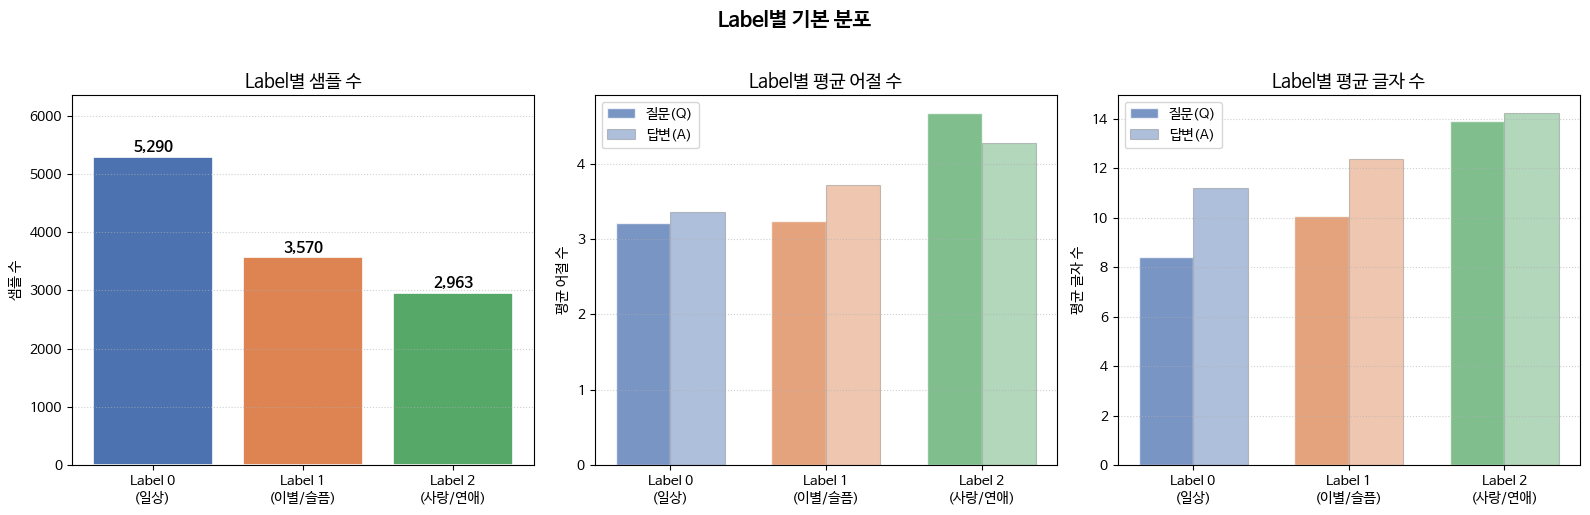

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Label별 기본 분포', fontsize=15, fontweight='bold', y=1.02)

labels      = sorted(eda_df['label'].unique())
label_ticks = [label_names[l] for l in labels]
colors      = [label_colors[l] for l in labels]

# (1) Label별 샘플 수
counts = [label_counts[l] for l in labels]
bars = axes[0].bar(label_ticks, counts, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Label별 샘플 수', fontsize=13)
axes[0].set_ylabel('샘플 수')
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(counts) * 1.2)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# (2) Label별 Q·A 평균 어절 수
q_word_means = [eda_df[eda_df['label']==l]['Q_word_len'].mean() for l in labels]
a_word_means = [eda_df[eda_df['label']==l]['A_word_len'].mean() for l in labels]
x = range(len(labels))
w = 0.35
axes[1].bar([i - w/2 for i in x], q_word_means, width=w, label='질문(Q)',
            color=[c + '99' for c in ['#4C72B0', '#DD8452', '#55A868']]
            if False else colors, alpha=0.75, edgecolor='white')
axes[1].bar([i + w/2 for i in x], a_word_means, width=w, label='답변(A)',
            color=colors, alpha=0.45, edgecolor='grey', linewidth=0.8)
axes[1].set_title('Label별 평균 어절 수', fontsize=13)
axes[1].set_ylabel('평균 어절 수')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(label_ticks)
axes[1].legend(); axes[1].grid(axis='y', linestyle=':', alpha=0.6)

# (3) Label별 Q·A 평균 글자 수
q_char_means = [eda_df[eda_df['label']==l]['Q_char_len'].mean() for l in labels]
a_char_means = [eda_df[eda_df['label']==l]['A_char_len'].mean() for l in labels]
axes[2].bar([i - w/2 for i in x], q_char_means, width=w, label='질문(Q)',
            color=colors, alpha=0.75, edgecolor='white')
axes[2].bar([i + w/2 for i in x], a_char_means, width=w, label='답변(A)',
            color=colors, alpha=0.45, edgecolor='grey', linewidth=0.8)
axes[2].set_title('Label별 평균 글자 수', fontsize=13)
axes[2].set_ylabel('평균 글자 수')
axes[2].set_xticks(list(x)); axes[2].set_xticklabels(label_ticks)
axes[2].legend(); axes[2].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

- 가장 많은 레이블 (일상)과 가장 적은 레이블 (사랑/연애)가 약 1.8배 차이 나는 불균형한 클래스 분포를 보인다.

- 평균 어절/글자 수는 Label 2(사랑/연애)가 가장 길고 Label 0(일상)이 가장 짧다.

> 글자 수와 어절 수를 함께 보는 이유는 뭘까?
> 두 지표는 서로 다른 언어적 현상을 포착한다. 어절 수는 문장의 구조적 복잡도를 반영하고, 글자 수는 정보 밀도를 반영한다.

> 한국어는 교착어라서 이 둘이 특히 더 잘 분리되는데, 예를 들어 "갔었겠니?"는 어절 수로는 1개지만 글자 수는 6개고, 형태소는 4개이다. 반면 "나 밥 먹어"는 어절 3개지만 글자는 5개에 불과하다. 어절 수만 보면 전자가 더 단순해 보이지만, 실제 문장이 담고 있는 문법 정보는 훨씬 풍부한 것이다.

> 그래서 둘을 같이 봐야 어절당 평균 글자 수, 즉 형태소 밀도를 간접적으로 추정할 수 있다. 만약 어절 수는 비슷한데 글자 수가 특정 레이블에서 유독 길다면 그 레이블의 문장이 복합 용언이나 경어체처럼 형태적으로 복잡한 표현을 자주 쓴다는 신호로 볼 수 있다.

### 2-3. Label별 Q & A 어절 수 분포 (히스토그램 + KDE)

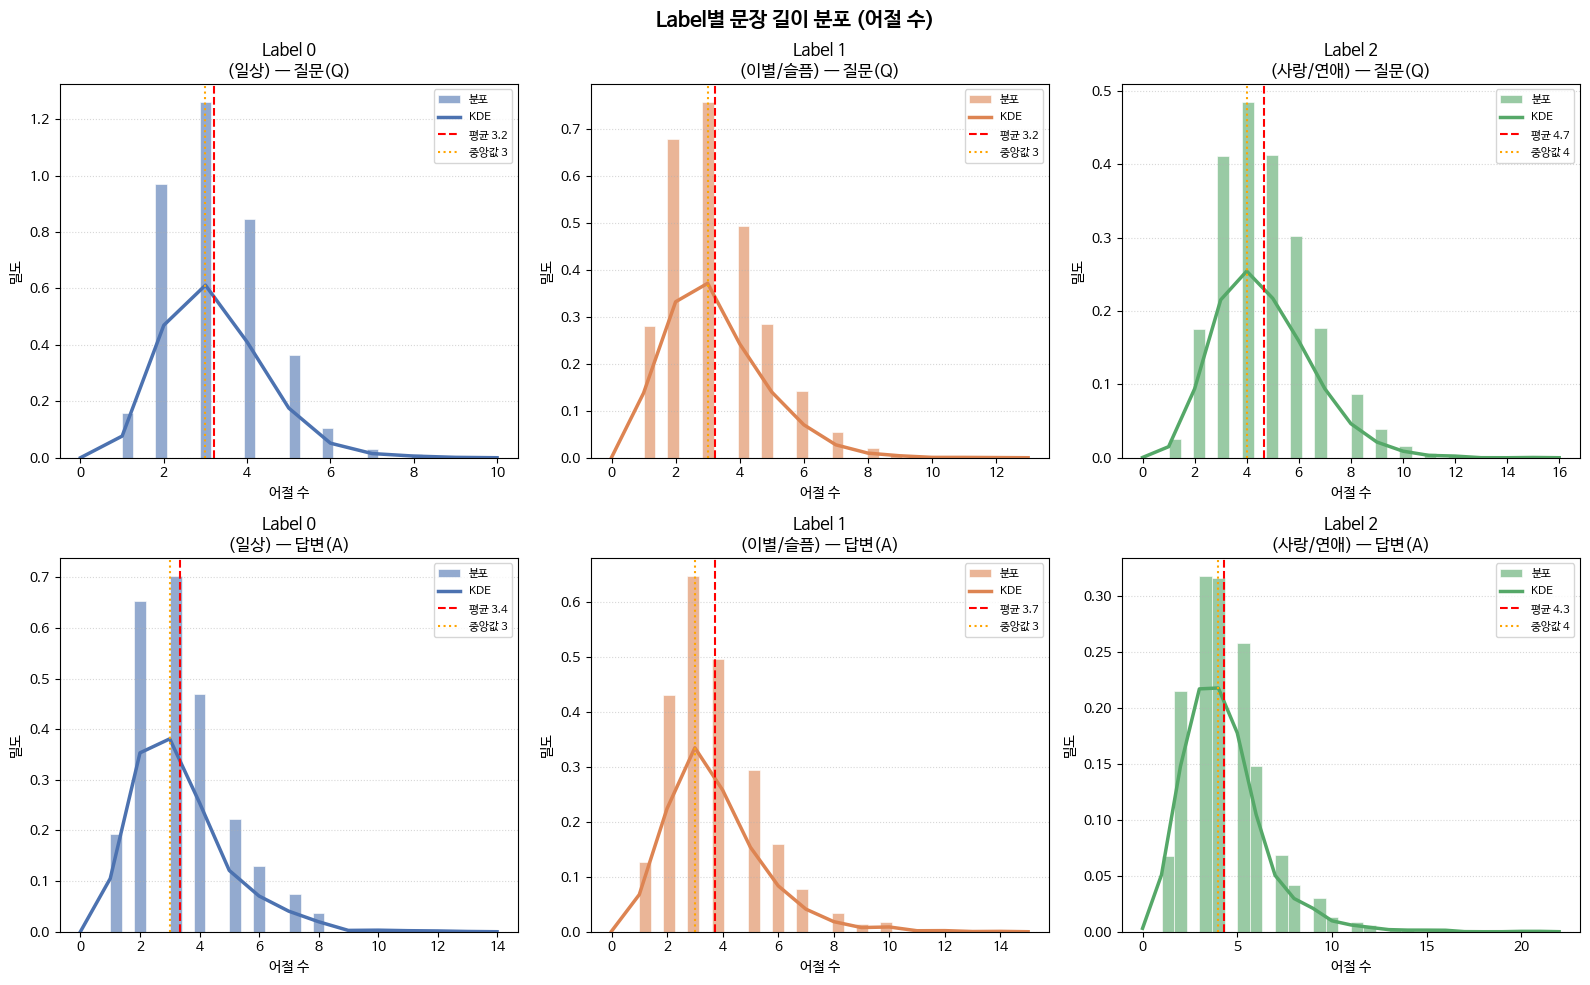

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Label별 문장 길이 분포 (어절 수)', fontsize=15, fontweight='bold')

for col_idx, label in enumerate(labels):
    subset = eda_df[eda_df['label'] == label]
    color  = label_colors[label]

    for row_idx, (col, title_prefix) in enumerate([('Q_word_len', '질문(Q)'), ('A_word_len', '답변(A)')]):
        ax     = axes[row_idx][col_idx]
        data   = subset[col]
        mean_v = data.mean()
        med_v  = data.median()

        # 히스토그램
        ax.hist(data, bins=30, color=color, alpha=0.6, edgecolor='white', linewidth=0.7,
                density=True, label='분포')

        # KDE 곡선
        try:
            from scipy.stats import gaussian_kde
            kde  = gaussian_kde(data)
            x_r  = range(0, int(data.max()) + 2)
            ax.plot(list(x_r), kde(list(x_r)), color=color, linewidth=2.5, label='KDE')
        except Exception:
            pass  # scipy 없으면 KDE 생략

        # 평균·중앙값 표시
        ax.axvline(mean_v, color='red',    linestyle='--', linewidth=1.5, label=f'평균 {mean_v:.1f}')
        ax.axvline(med_v,  color='orange', linestyle=':',  linewidth=1.5, label=f'중앙값 {med_v:.0f}')

        ax.set_title(f'{label_names[label]} — {title_prefix}', fontsize=12)
        ax.set_xlabel('어절 수')
        ax.set_ylabel('밀도')
        ax.legend(fontsize=8)
        ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 2-4. Label별 Q & A 글자 수 분포

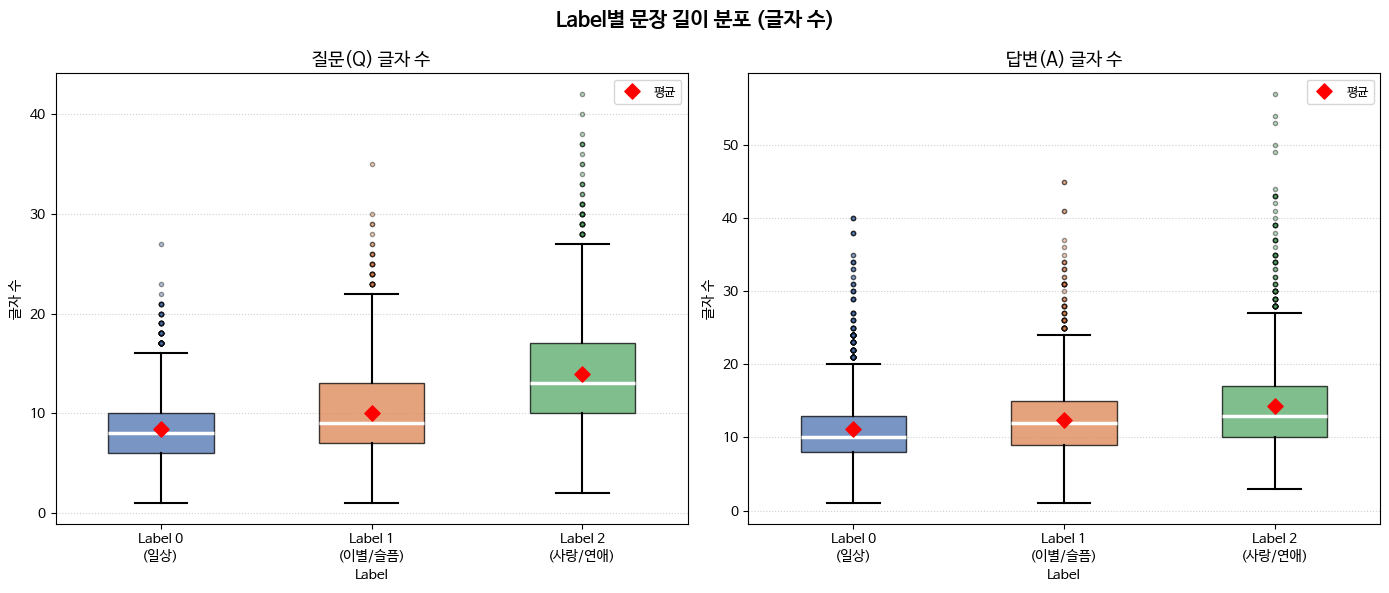

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Label별 문장 길이 분포 (글자 수)', fontsize=15, fontweight='bold')

for ax_idx, (col, title) in enumerate([('Q_char_len', '질문(Q) 글자 수'), ('A_char_len', '답변(A) 글자 수')]):
    ax = axes[ax_idx]

    data_by_label = [eda_df[eda_df['label'] == l][col].values for l in labels]

    bp = ax.boxplot(
        data_by_label,
        patch_artist=True,
        notch=False,
        widths=0.5,
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )

    for patch, label in zip(bp['boxes'], labels):
        patch.set_facecolor(label_colors[label])
        patch.set_alpha(0.75)
        bp['fliers'][labels.index(label)].set_markerfacecolor(label_colors[label])

    # 평균값 표시
    for i, (data, label) in enumerate(zip(data_by_label, labels), start=1):
        mean_v = data.mean()
        ax.scatter(i, mean_v, color='red', zorder=5, s=60, marker='D', label='평균' if i == 1 else '')

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Label')
    ax.set_ylabel('글자 수')
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(label_ticks)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 2-5. Q 길이 vs A 길이 산점도

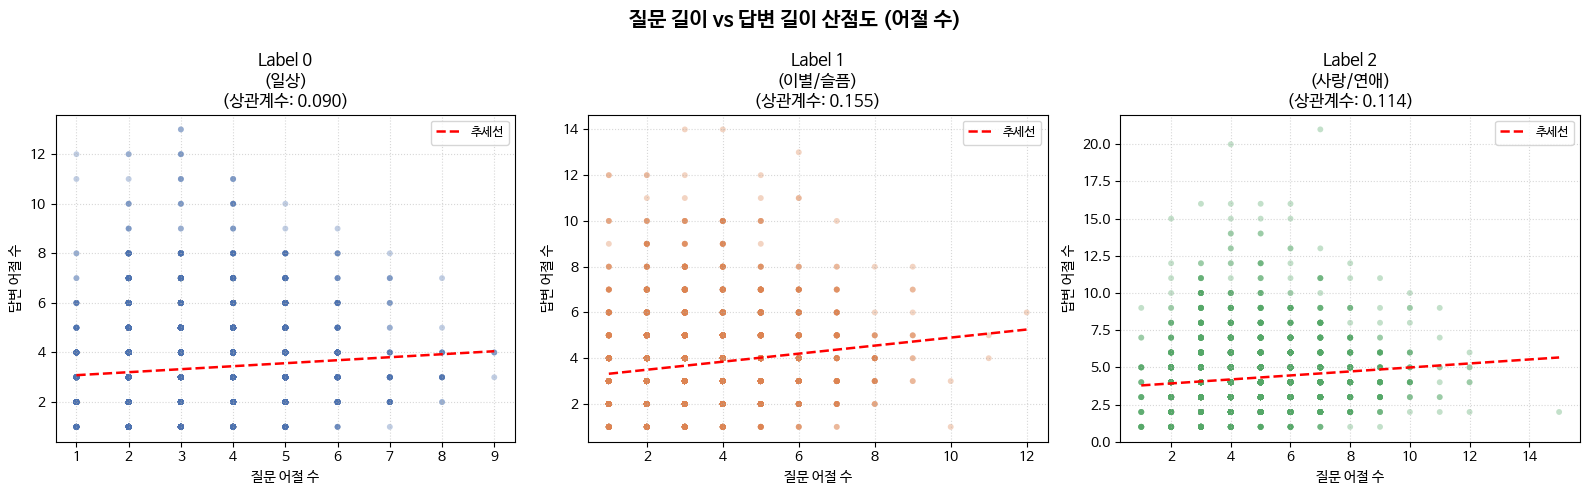

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('질문 길이 vs 답변 길이 산점도 (어절 수)', fontsize=15, fontweight='bold')

for col_idx, label in enumerate(labels):
    ax     = axes[col_idx]
    subset = eda_df[eda_df['label'] == label]
    color  = label_colors[label]

    ax.scatter(subset['Q_word_len'], subset['A_word_len'],
               color=color, alpha=0.35, s=18, edgecolors='none')

    # 추세선
    try:
        z = np.polyfit(subset['Q_word_len'], subset['A_word_len'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(subset['Q_word_len'].min(), subset['Q_word_len'].max(), 100)
        ax.plot(x_line, p(x_line), color='red', linewidth=1.8, linestyle='--', label='추세선')
    except Exception:
        pass

    corr = subset['Q_word_len'].corr(subset['A_word_len'])
    ax.set_title(f'{label_names[label]}\n(상관계수: {corr:.3f})', fontsize=12)
    ax.set_xlabel('질문 어절 수')
    ax.set_ylabel('답변 어절 수')
    ax.legend(fontsize=9)
    ax.grid(linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 2-6. EDA 기반 전략 도출

1. max_seq_len 재검토 -> 불필요한 패딩을 줄이고 학습 속도를 높일 수 있음 
2. 클래스 불균형 대응 -> weighted sampling
3. Label 2 집중 증강
4. Q-A 상관 무시 전략 유지

## 3. 학습 데이터셋 구성

### 3-1. 정제 함수 정의

In [12]:
def preprocess_sentence(sentence):
    """
    한국어 텍스트 전처리 함수 (Ex09 재사용)
    1. 영문자 → 소문자 변환
    2. 연속 구두점 정규화 (!!!→!, ???→?)
    3. 한글·영문·숫자·주요 문장부호(?.!,) 외 제거
    4. 중복 공백 제거 및 앞뒤 공백 제거
    """
    if not isinstance(sentence, str):
        return ""

    sentence = sentence.lower()                                    # 소문자 변환
    sentence = re.sub(r'([!?.]){2,}', r'\1', sentence)            # 연속 구두점 정규화
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)   # 불필요한 문자 제거
    sentence = re.sub(r'\s+', ' ', sentence)                       # 중복 공백 제거

    return sentence

In [13]:
# 전처리 예시 확인
sample_sentences = [
    "오늘 #진짜 너무 힘들다!!!",       # 노이즈 → 증강 전 제거해야 할 케이스
    "Hello World... 테스트 #@$",
    "  중복   공백   테스트  ",
    df['Q'].iloc[0]
]
print("\n=== 전처리 예시 ===\n")
for s in sample_sentences:
    print(f"원본: {repr(s)}")
    print(f"정제: {repr(preprocess_sentence(s))}\n")


=== 전처리 예시 ===

원본: '오늘 #진짜 너무 힘들다!!!'
정제: '오늘 진짜 너무 힘들다!'

원본: 'Hello World... 테스트 #@$'
정제: 'hello world. 테스트 '

원본: '  중복   공백   테스트  '
정제: ' 중복 공백 테스트 '

원본: '12시 땡!'
정제: '12시 땡!'



### 3-2. 훈련/검증 데이터셋 분할

**데이터 누수(data leakage) 방지를 위해** 토큰화 및 단어 사전 구축 전에 먼저 분할한다.

In [14]:
split_idx = int(len(questions) * 0.9) # 9:1 비율로 분할

questions_train = questions[:split_idx]
answers_train   = answers[:split_idx]
questions_val   = questions[split_idx:]
answers_val     = answers[split_idx:]

print(f"훈련 데이터: {len(questions_train):,}건")
print(f"검증 데이터: {len(questions_val):,}건")

훈련 데이터: 10,640건
검증 데이터: 1,183건


***다음 단계로 가기에 앞서 <토큰화 - 증강 - 벡터화 순서 관련>**

데이터 정제와 필터링을 수행해 토큰 리스트를 만드는 `build_corpus`를 word_index를 만드는 `generate_tokenizer`보다 먼저 배치하여, 실제 학습에 사용될 유효한 토큰들로만 사전을 구성한다. 특히 <3-4>의 데이터 증강(Augmentation)으로 새로 생성된 단어들까지 모두 사전에 포함시키기 위해, 최종 증강이 완료된 시점에 단어 번호를 부여하는 것이 Mecab 형태소 분석기를 이용할 때 가장 효율적이다. 이를 통해 불필요한 노이즈 토큰을 제거하고 모델이 학습해야 할 단어 집합의 밀도를 높일 수 있다.

### 3-3. 토큰화

질문과 답변이 모두 한국어이므로 하나의 공유 토크나이저를 (Mecab) 사용한다.  (번역기에서 임베딩 공유 이점과 동일한 원리)

In [15]:
mecab = Mecab() # 토크나이저 선언

MAX_LEN = 30 # 길이 필터 설정
            # EDA 근거: 어절 수 10이하 집중 -> 형태소 기준 ~30

def build_corpus(src_data, tgt_data, tokenize_fn, max_len=MAX_LEN):
    """
    1. 소스·타겟 문장 입력
    2. preprocess_sentence()로 정제 후 tokenize_fn으로 토큰화
    3. 토큰 수 MAX_LEN 이상 제외
    4. 소스는 소스대로, 타겟은 타겟대로 중복 제거 (쌍 순서 유지)
        - 두 set 모두 처음 등장하는 쌍만 수집 → 쌍 순서 보장
    """
    src_corpus, tgt_corpus = [], []
    seen_src, seen_tgt = set(), set()

    for src, tgt in tqdm(zip(src_data, tgt_data),
                         total=len(src_data), desc='build_corpus'):
        src_clean  = preprocess_sentence(src)
        tgt_clean  = preprocess_sentence(tgt)
        if not src_clean or not tgt_clean:
            continue

        src_tokens = tokenize_fn(src_clean)
        tgt_tokens = tokenize_fn(tgt_clean)

        if len(src_tokens) >= max_len or len(tgt_tokens) >= max_len:
            continue

        src_key = tuple(src_tokens)
        tgt_key = tuple(tgt_tokens)
        if src_key in seen_src or tgt_key in seen_tgt:
            continue

        seen_src.add(src_key); seen_tgt.add(tgt_key)
        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    return src_corpus, tgt_corpus

In [16]:
# 훈련 데이터만 build_corpus 적용
MAX_LEN = 30   # EDA 근거: 어절 수 10이하 집중 -> 형태소 기준 ~30

que_corpus, ans_corpus = build_corpus(questions_train, answers_train, mecab.morphs, MAX_LEN)

print(f"build_corpus 완료: {len(que_corpus):,}개 쌍")
print("\n=== 토큰화 예시 ===")
for i in range(3):
    print(f"  원문       : {questions_train[i]}")
    print(f"  que_corpus : {que_corpus[i]}")
    print(f"  ans_corpus : {ans_corpus[i]}\n")

build_corpus:   0%|          | 0/10640 [00:00<?, ?it/s]

build_corpus 완료: 6,726개 쌍

=== 토큰화 예시 ===
  원문       : 12시 땡!
  que_corpus : ['12', '시', '땡', '!']
  ans_corpus : ['하루', '가', '또', '가', '네요', '.']

  원문       : 1지망 학교 떨어졌어
  que_corpus : ['1', '지망', '학교', '떨어졌', '어']
  ans_corpus : ['위로', '해', '드립니다', '.']

  원문       : 3박4일 놀러가고 싶다
  que_corpus : ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
  ans_corpus : ['여행', '은', '언제나', '좋', '죠', '.']



### 3-4. 데이터 증강

한국어 Word2Vec 모델(`ko.bin`)을 사용한 **Lexical Substitution**

증강 전략:
**Lexical Substitution**: 문장 내 토큰 중 하나를 Word2Vec 유사 단어로 대체
- 증강된 질문 + 원본 답변 쌍
- 원본 질문 + 증강된 답변 쌍
Random Augmentation: 어휘 사전에 없는 토큰이 많은 문장을 보완
   - `delete`: 무작위 단어 1개 삭제
   - `swap`  : 두 단어 위치 교환

Lexical Substitution 시도 후 어휘 미등록으로 실패한 문장에 한해 Random Augment로 대체하여 전체 데이터가 원래의 3배(약 35,469건)가 되도록 구성한다.

In [17]:
# ko.bin (Korean Word2Vec) 다운로드
KO_MODEL_PATH = './data/word2vec_ko.model'

if os.path.exists(KO_MODEL_PATH):
    print(f"word2vec_ko.model이 이미 존재합니다 → 다운로드를 건너뜁니다: {KO_MODEL_PATH}")
else:
    print(" 한국어 Word2Vec 모델(ko.bin)을 다운로드합니다...")
    print("   (출처: https://github.com/Kyubyong/wordvectors — Korean (w) 모델)")
    KO_ZIP_URL = "https://onedrive.live.com/download?cid=648E1F0C58B01026&resid=648E1F0C58B01026%21338&authkey=AHAw7wlFhWJbBFk"

    # OneDrive 직접 다운로드가 막힐 경우를 대비한 안내 메시지
    try:
        urllib.request.urlretrieve(KO_ZIP_URL, 'ko.zip')
        with zipfile.ZipFile('ko.zip', 'r') as z:
            z.extractall('.')
        os.remove('ko.zip')
        print(" 다운로드 및 압축 해제 완료!")
    except Exception as e:
        print(f" 자동 다운로드 실패: {e}")
        print("   아래 방법으로 수동 다운로드 후 ko.bin을 현재 디렉토리에 위치시켜 주세요.")
        print("   https://github.com/Kyubyong/wordvectors")
        print("      → 'Korean (w)' 링크 클릭 → ko.bin 파일 추출")

word2vec_ko.model이 이미 존재합니다 → 다운로드를 건너뜁니다: ./data/word2vec_ko.model


In [18]:
# Word2Vec 모델 로드
print(" ko.bin 모델을 로드합니다 (binary 형식)...")
wv = Word2Vec.load(KO_MODEL_PATH).wv
print(f" 모델 로드 완료! 어휘 크기: {len(wv):,}개")

# 간단 동작 확인
sample_word = "행복"
if sample_word in wv:
    similar = wv.most_similar(sample_word, topn=5)
    print(f"\n'{sample_word}'의 유사 단어 Top 5:")
    for word, score in similar:
        print(f"  {word}: {score:.4f}")

 ko.bin 모델을 로드합니다 (binary 형식)...
 모델 로드 완료! 어휘 크기: 302,960개

'행복'의 유사 단어 Top 5:
  사랑: 0.7550
  소중: 0.7271
  고독: 0.7224
  영원: 0.7197
  친절: 0.7095


In [19]:
def lexical_sub(token_list, wv):
    """
    형태소 토큰 리스트에서 Word2Vec 어휘에 존재하는 단어 하나를 가장 유사한 단어로 대체.
    어휘 내 단어가 없으면 None 반환.
    """
    valid = [tok for tok in token_list if tok in wv]
    
    if not valid:
        return None # 대체 불가 → 호출 측에서 fallback 처리
        
    selected = random.choice(valid)
    similar  = wv.most_similar(selected, topn=1)[0][0]
    
    return [similar if tok == selected else tok for tok in token_list]

def augment_corpus(token_list, wv):
    """
    Lexical Substitution 실패 시 사용하는 fallback 증강.
    delete / swap / keep 중 하나를 무작위 적용.
    """
    result = lexical_sub(token_list, wv)
    
    if result is not None:
        return result
        
    tokens = token_list[:]
    if len(tokens) < 2:
        return tokens
        
    method = random.choice(['delete', 'swap', 'keep'])
    if method == 'delete':
        tokens.pop(random.randint(0, len(tokens)-1))
    elif method == 'swap':
        i1, i2 = random.sample(range(len(tokens)), 2)
        tokens[i1], tokens[i2] = tokens[i2], tokens[i1]
        
    return tokens

In [20]:
print("=== Lexical Substitution 예시 ===")
print(f"원본: {que_corpus[0]}")
for _ in range(3):
    print(f"증강: {augment_corpus(que_corpus[0], wv)}")

=== Lexical Substitution 예시 ===
원본: ['12', '시', '땡', '!']
증강: ['11', '시', '땡', '!']
증강: ['11', '시', '땡', '!']
증강: ['12', '시', '돌이', '!']


In [21]:
# 훈련 데이터에만 증강 적용
print(f"증강 전: {len(que_corpus):,}건")

aug_que = [augment_corpus(q, wv) for q in tqdm(que_corpus, desc='질문 증강')]
aug_ans = [augment_corpus(a, wv) for a in tqdm(ans_corpus, desc='답변 증강')]

que_corpus = que_corpus + aug_que    + que_corpus   # 원본 + 케이스1 + 케이스2
ans_corpus = ans_corpus + ans_corpus + aug_ans

print(f"증강 후: {len(que_corpus):,}건  (원본의 3배)")
print("\n=== 증강 샘플 ===\n")
for i in range(2):
    print(f"  원본: {que_corpus[i]}")
    print(f"  증강: {aug_que[i]}\n")

증강 전: 6,726건


질문 증강:   0%|          | 0/6726 [00:00<?, ?it/s]

답변 증강:   0%|          | 0/6726 [00:00<?, ?it/s]

증강 후: 20,178건  (원본의 3배)

=== 증강 샘플 ===

  원본: ['12', '시', '땡', '!']
  증강: ['12', '시경', '땡', '!']

  원본: ['1', '지망', '학교', '떨어졌', '어']
  증강: ['1', '전업', '학교', '떨어졌', '어']



### 3-5. 데이터 벡터화

- ans_corpus에 <start>, <end> 토큰 추가

- generate_tokenizer: 훈련 데이터로 공유 사전 구축
(**질문과 답변이 모두 한국어이므로 공유 사전으로 임베딩 층 공유**)

- pad_sequences_custom으로 훈련/검증 모두 패딩

In [22]:
# 훈련 ans_corpus에만 <start>/<end> 추가
ans_corpus = [["<start>"] + a + ["<end>"] for a in ans_corpus]

print("=== <start>/<end> 추가 예시 ===")
print(f"  que_corpus[0]: {que_corpus[0]}")
print(f"  ans_corpus[0]: {ans_corpus[0]}")

=== <start>/<end> 추가 예시 ===
  que_corpus[0]: ['12', '시', '땡', '!']
  ans_corpus[0]: ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']


In [23]:
def generate_tokenizer(sentences, tokenize_fn,
                       pad_id=0,   # <pad>   토큰 ID
                       bos_id=1,   # <start> 토큰 ID
                       eos_id=2,   # <end>   토큰 ID
                       unk_id=3):  # <unk>   토큰 ID
    """
    훈련 데이터 문장으로 공유 사전 구축.
    - 특수 토큰 ID 고정 (항상 같은 ID 보장)
    - 내부에서 정제 + tokenize_fn 토큰화 후 사전 등록
    - 훈련 데이터에만 적용; 검증 데이터는 반환된 word_index로 변환만 수행
    """
    word_index = {
        '<pad>':   pad_id,
        '<start>': bos_id,
        '<end>':   eos_id,
        '<unk>':   unk_id,
    }
    idx = unk_id + 1

    for sentence in tqdm(sentences, desc='generate_tokenizer'):
        clean  = preprocess_sentence(sentence)
        tokens = tokenize_fn(clean)
        for token in tokens:
            if token not in word_index:
                word_index[token] = idx
                idx += 1

    index_word = {v: k for k, v in word_index.items()}
    return word_index, index_word

In [24]:
# 훈련 데이터 (questions_train + answers_train)로 공유 사전 구축
word_index, index_word = generate_tokenizer(
    questions_train + answers_train, mecab.morphs
)

VOCAB_SIZE = len(word_index) + 1   # +1: pad(0) 예약
START_IDX  = word_index['<start>']
END_IDX    = word_index['<end>']
UNK_IDX    = word_index['<unk>']

print(f"단어 사전 크기: {VOCAB_SIZE:,}")
print(f"<pad>   ID : 0")
print(f"<start> ID : {START_IDX}")
print(f"<end>   ID : {END_IDX}")
print(f"<unk>   ID : {UNK_IDX}")

generate_tokenizer:   0%|          | 0/21280 [00:00<?, ?it/s]

단어 사전 크기: 6,527
<pad>   ID : 0
<start> ID : 1
<end>   ID : 2
<unk>   ID : 3


In [25]:
MAX_SEQ_LEN = 50   # MAX_LEN=30 형태소 필터 후, <start>/<end> 추가 고려

def pad_sequences_custom(sequences, max_len=MAX_SEQ_LEN, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len  : 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []
    for seq in sequences:
        if len(seq) > max_len:
            seq = seq[:max_len]
        else:
            seq = seq + [pad_value] * (max_len - len(seq))
        padded_sequences.append(seq)
    
    # 최종적으로 torch.Tensor로 변환 (shape: [num_samples, max_len])
    return torch.tensor(padded_sequences, dtype=torch.long)

In [26]:
# 훈련 데이터: que_corpus, ans_corpus -> ID 변환 -> 패딩
enc_input = [[word_index.get(tok, UNK_IDX) for tok in toks] for toks in que_corpus]
dec_input = [[word_index.get(tok, UNK_IDX) for tok in toks] for toks in ans_corpus]

enc_train = pad_sequences_custom(enc_input, max_len=MAX_SEQ_LEN, pad_value=0)
dec_train = pad_sequences_custom(dec_input, max_len=MAX_SEQ_LEN, pad_value=0)

print(f"enc_train shape: {enc_train.shape}")
print(f"dec_train shape: {dec_train.shape}")
print(f"\nenc_train[0]: {enc_train[0].tolist()}")
print(f"dec_train[0]: {dec_train[0].tolist()}")

enc_train shape: torch.Size([20178, 50])
dec_train shape: torch.Size([20178, 50])

enc_train[0]: [4, 5, 6, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
dec_train[0]: [1, 549, 19, 328, 19, 1918, 91, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


**인코딩 예시가 틀린 거 아닌가? 왜 시작 토큰 (1)과 종료 토큰 (2)가 없을까?**

트랜스포머의 인코더는 질문(Source) 전체를 한꺼번에 입력받아 **문맥 정보 (context)** 를 추출하는 역할만을 하기 때문이다.

- **시작 토큰(1)이 없는 이유:** 인코더는 문장을 생성하는 게 아니라 읽는 역할입니다. 어디서 시작하는지 알려줄 필요 없이 입력된 문장 전체를 한 번에 self-attention으로 처리하기 때문이다.

- **종료 토큰(2)이 없는 이유:** 질문의 길이는 패딩(0)이 시작되는 지점을 통해 모델이 알 수 있기 때문이다.

In [27]:
# 검증 데이터: 정제 + mecab 토큰화 + 같은 word_index 변환 + 패딩
# build_corpus(길이 필터·중복 제거) 미적용 -> 검증 데이터 온전히 보존
def encode_sentence(sentence, tokenize_fn, word_index, unk_id=UNK_IDX):
    """문장 1개를 정제 -> 토큰화 -> ID 변환."""
    clean  = preprocess_sentence(sentence)
    tokens = tokenize_fn(clean)
    return [word_index.get(tok, unk_id) for tok in tokens]

enc_val_input = [encode_sentence(q, mecab.morphs, word_index)
                 for q in tqdm(questions_val, desc='val Q 인코딩')]
dec_val_input = [[word_index.get(tok, UNK_IDX) for tok in
                  ["<start>"] + mecab.morphs(preprocess_sentence(a)) + ["<end>"]]
                 for a in tqdm(answers_val, desc='val A 인코딩')]

enc_val = pad_sequences_custom(enc_val_input, max_len=MAX_SEQ_LEN, pad_value=0)
dec_val = pad_sequences_custom(dec_val_input, max_len=MAX_SEQ_LEN, pad_value=0)

print(f"enc_val shape: {enc_val.shape}")
print(f"dec_val shape: {dec_val.shape}")

val Q 인코딩:   0%|          | 0/1183 [00:00<?, ?it/s]

val A 인코딩:   0%|          | 0/1183 [00:00<?, ?it/s]

enc_val shape: torch.Size([1183, 50])
dec_val shape: torch.Size([1183, 50])


### 3-6. DataLoader 생성

EDA 전략 적용: Label 0(5290) vs Label 2(2963) 약 1.8배 불균형 -> WeightedRandomSampler를 적용해 Label 불균형 보정

In [28]:
# 훈련 레이블: 원본 label을 3배로 복제 (원본+케이스1+케이스2), 길이 맞춤
labels_train = (df['label'].tolist()[:split_idx] * 3)[:len(enc_train)]
label_cnt    = np.bincount(np.array(labels_train))
print(f"훈련 레이블 분포: { {i: c for i, c in enumerate(label_cnt)} }")

weights_per_lbl = 1.0 / label_cnt.astype(float)
sample_weights  = torch.tensor([weights_per_lbl[l] for l in labels_train], dtype=torch.float)
sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

훈련 레이블 분포: {0: np.int64(10580), 1: np.int64(7140), 2: np.int64(2458)}


In [29]:
BATCH_SIZE    = 128
train_dataset = TensorDataset(enc_train, dec_train)
val_dataset   = TensorDataset(enc_val,   dec_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  pin_memory=True)

print(f"학습 데이터: {len(train_dataset):,}건  /  검증: {len(val_dataset):,}건")
print(f"학습 배치 수: {len(train_loader)}  /  검증 배치 수: {len(val_loader)}")

학습 데이터: 20,178건  /  검증: 1,183건
학습 배치 수: 158  /  검증 배치 수: 10


## 4. 트랜스포머 모델 구현

구성: PositionalEncoding → Encoder → Decoder → Transformer

In [30]:
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2 * (i // 2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    
    # 짝수 인덱스는 sin, 홀수 인덱스는 cos
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    
    # 모델에서 바로 사용할 수 있도록 torch.FloatTensor로 변환하여 반환
    return torch.FloatTensor(sinusoid_table)

In [31]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    # 패딩 토큰(0)인 부분을 1로, 나머지는 0으로 설정
    # Attention Score에 더해질 것이므로 float 타입으로 변환
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()

def generate_lookahead_mask(size: int, device: torch.device) -> torch.Tensor:
    # 상삼각 행렬(diagonal=1)을 생성하여 미래 토큰을 마스킹
    mask = torch.triu(torch.ones((size, size), device=device), diagonal=1)
    return mask.float()

def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    # 입력 텐서의 현재 장치(device)를 자동으로 감지
    device = src.device
    
    # 1. Encoder Padding Mask
    enc_mask = generate_padding_mask(src).to(device)
    
    # 2. Decoder-Encoder (Cross) Attention Mask
    # 디코더가 엔코더의 패딩 영역을 보지 못하게 함
    dec_enc_mask = generate_padding_mask(src).to(device)
    
    # 3. Decoder Self-Attention Mask (Look-ahead + Padding)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1], device)
    dec_tgt_padding_mask = generate_padding_mask(tgt).to(device)
    
    # Look-ahead 마스크의 차원을 Padding 마스크와 맞춤 (batch, 1, seq_len, seq_len)
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)
    
    # 두 마스크를 합침: 패딩이거나 미래 단어인 경우 모두 1이 됨
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)
    
    return enc_mask, dec_enc_mask, dec_mask

In [32]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model   = d_model
        self.depth     = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k      = Q.size(-1)
        QK       = torch.matmul(Q, K.transpose(-1, -2))
        scaled   = QK / math.sqrt(d_k)

        if mask is not None:
            scaled = scaled + (mask * -1e9)

        attentions = F.softmax(scaled, dim=-1)
        out        = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ = self.split_heads(WQ)
        WK = self.split_heads(WK)
        WV = self.split_heads(WV)

        out, attn_weights = self.scaled_dot_product_attention(WQ, WK, WV, mask)
        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attn_weights

In [33]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout) # 드롭아웃 추가 -> 과적합 방지 장치

    def forward(self, x):
        return self.fc2(self.dropout(self.relu(self.fc1(x))))

In [34]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn    = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.do     = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out) + residual

        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out) + residual

        return out, enc_attn

In [35]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn  = MultiHeadAttention(d_model, num_heads)
        self.ffn    = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.do     = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out) + residual

        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out) + residual

        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out) + residual

        return out, dec_attn, dec_enc_attn

In [36]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers  = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        out, enc_attns = x, []
        for layer in self.enc_layers:
            out, enc_attn = layer(out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

In [37]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers  = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out, dec_attns, dec_enc_attns = x, [], []
        for layer in self.dec_layers:
            out, dec_attn, dec_enc_attn = layer(out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

In [38]:
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=True):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)

        # 챗봇은 질문·답변이 같은 언어 → 임베딩 공유로 성능 향상
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        pos_enc = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_enc, dtype=torch.float32))

        self.do      = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc      = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            self.fc.weight = self.dec_emb.weight  # fc와 dec_emb 가중치 공유

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)
        if self.shared_fc:
            out = out * math.sqrt(self.d_model) # embedding scaling 
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        return self.do(out)

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_emb = self.embedding(self.enc_emb, enc_in)
        dec_emb = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns                  = self.encoder(enc_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns   = self.decoder(dec_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

**트랜스포머에서 임베딩에 모델 차원의 제곱근을 곱하는 이유는 뭘까?**

임베딩 값이 너무 작으면 그 위에 포지셔널 인코딩을 더했을 때 스케일 차이로 인해 단어의 의미(embedding) 정보는 사라지고 위치 정보(position)만 남게 된다.

따라서 임베딩에 모델 차원의 제곱근을 곱해서 값을 크게 키워주면 단어 의미 정보가 위치 정보에 묻히지 않고 적절한 비율로 유지될 수 있다.

## 5. 학습 관련 함수 정의

과적합 방지 전략 추가 적용:
- Label Smoothing (CrossEntropyLoss)
  
- Gradient Clipping

- Learning Rate Warm-up Scheduling

- Early Stopping

In [39]:
# 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


In [40]:
def accuracy_function(predictions, targets, pad_id=0):
    """
    predictions: (batch, seq_len, vocab_size)
    targets    : (batch, seq_len)
    """
    preds   = predictions.argmax(dim=-1)
    mask    = (targets != pad_id)
    correct = (preds == targets) & mask
    return correct.float().sum() / mask.float().sum()

In [41]:
def get_lr_lambda(d_model, warmup_steps=4000):
    """Transformer 논문의 warmup LR 스케줄러"""
    d_model = float(d_model)
    def lr_lambda(step):
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

In [42]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device, pad_token):
    """1 에폭 학습 (gradient clipping 포함)"""
    model.train()
    total_loss, total_acc = 0.0, 0.0

    pbar = tqdm(dataloader, desc='Training')

    for batch in pbar:
        enc_input  = batch[0].to(device)
        dec_full   = batch[1].to(device)
        dec_input  = dec_full[:, :-1]  # <start>~끝에서두번째
        dec_target = dec_full[:, 1:]   # 두번째~<end>

        enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_input, dec_input)

        optimizer.zero_grad()

        predictions, _, _, _ = model(enc_input, dec_input, enc_mask, dec_enc_mask, dec_mask)

        loss = criterion(
            predictions.contiguous().view(-1, predictions.size(-1)), 
            dec_target.contiguous().view(-1)
        )
        acc  = accuracy_function(predictions, dec_target, pad_id=pad_token)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # 기울기 폭주 방지
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        total_acc  += acc.item()

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{acc.item():.4f}'})

    n = len(dataloader)
    return total_loss / n, total_acc / n

In [43]:
def validate_epoch(model, dataloader, criterion, device, pad_token):
    """1 에폭 검증"""
    model.eval()
    total_loss, total_acc = 0.0, 0.0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Validation'):
            # 모든 입력 데이터를 GPU/CPU 기기로 이동
            enc_input  = batch[0].to(device)
            dec_full   = batch[1].to(device)
            
            # Teacher Forcing을 위한 데이터 슬라이싱
            dec_input  = dec_full[:, :-1]
            dec_target = dec_full[:, 1:]
            
            # 마스크 생성
            enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_input, dec_input)
            
            # 모델 예측
            predictions, _, _, _ = model(enc_input, dec_input, enc_mask, dec_enc_mask, dec_mask)
            
            # 손실 및 정확도 계산
            loss = criterion(
                predictions.contiguous().view(-1, predictions.size(-1)), 
                dec_target.contiguous().view(-1)
            )
            acc  = accuracy_function(predictions, dec_target, pad_id=pad_token)
            
            total_loss += loss.item()
            total_acc  += acc.item()
            
    n = len(dataloader)
    return total_loss / n, total_acc / n

In [44]:
def predict_answer(model, question, word_index, index_word, mecab, device,
                   max_len=MAX_SEQ_LEN, temperature=0.3):
    """
    온도 조절 샘플링 기반 답변 생성.
    - mecab.morphs로 토큰화 후 word_index로 벡터화
    - temperature 낮을수록 안정적, 높을수록 다양함
    """
    model.eval()

    START_TOKEN = word_index['<start>']
    END_TOKEN   = word_index['<end>']
    PAD_ID      = 0

    # 정제 -> 형태소 토큰화 -> 정수 인코딩 -> 패딩
    clean       = preprocess_sentence(question)
    tokens      = mecab.morphs(clean)
    enc_ids     = [word_index.get(t, 0) for t in tokens]
    enc_ids     = (enc_ids + [PAD_ID] * max_len)[:max_len]
    enc_tensor  = torch.tensor([enc_ids], dtype=torch.long).to(device)

    dec_list = [START_TOKEN]

    with torch.no_grad():
        for _ in range(max_len):
            dec_ids    = (dec_list + [PAD_ID] * max_len)[:max_len]
            dec_tensor = torch.tensor([dec_ids], dtype=torch.long).to(device)

            enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_tensor, dec_tensor)
            predictions, _, _, _ = model(
                enc_tensor, dec_tensor, enc_mask, dec_enc_mask, dec_mask
            )

            logits  = predictions[0, len(dec_list)-1, :] / temperature
            probs   = torch.softmax(logits, dim=-1)
            pred_id = torch.multinomial(probs, num_samples=1).item()

            if pred_id == END_TOKEN:
                break
            dec_list.append(pred_id)

    # 정수 -> 토큰 -> 문자열 복원 (<start> 제외)
    result_tokens = [index_word.get(i, '') for i in dec_list[1:]]
    return ' '.join(result_tokens).replace(' ', ' ').strip() # 형태소 분석기에 따라 공백 복원 필요

## 6. 모델 훈련

In [45]:
n_layers      = 2
d_model       = 256
n_heads       = 8 # d_model이 256일 때 각 헤드의 차원(depth)이 32가 되어 연산 효율이 좋음
d_ff          = 512 # 모델 경량화
dropout_rate  = 0.2

EPOCHS              = 100
learning_rate       = 1.0     # LambdaLR이 실질 lr 제어
warmup_steps        = 4000
inference_temp      = 0.3
early_stop_patience = 10

print("===== 하이퍼파라미터 =====")
print(f"n_layers     : {n_layers}")
print(f"d_model      : {d_model}")
print(f"n_heads      : {n_heads}")
print(f"d_ff         : {d_ff}")
print(f"dropout      : {dropout_rate}")
print(f"BATCH_SIZE   : {BATCH_SIZE}")
print(f"VOCAB_SIZE   : {VOCAB_SIZE:,}")
print(f"MAX_SEQ_LEN  : {MAX_SEQ_LEN}  (형태소 MAX_LEN={MAX_LEN} 필터 기반)")
print(f"warmup_steps : {warmup_steps}")
print(f"device       : {device}")

===== 하이퍼파라미터 =====
n_layers     : 2
d_model      : 256
n_heads      : 8
d_ff         : 512
dropout      : 0.2
BATCH_SIZE   : 128
VOCAB_SIZE   : 6,527
MAX_SEQ_LEN  : 50  (형태소 MAX_LEN=30 필터 기반)
warmup_steps : 4000
device       : cuda


In [46]:
# 모델 초기화
set_seed(42)

model = Transformer(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=MAX_SEQ_LEN,
    dropout=dropout_rate,
    shared_fc=True,
    shared_emb=True    # 챗봇: 질문/답변 동일 언어 -> 임베딩 공유
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터: {total_params:,}")

전체 파라미터: 4,313,215


In [47]:
PAD_ID = 0 # 패딩 인덱스 = 0 

# 손실함수
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID,
    label_smoothing=0.1    # 과적합 방지
)

# 옵티마이저
optimizer = optim.Adam(
    model.parameters(), lr=learning_rate,
    betas=(0.9, 0.98), eps=1e-9, weight_decay=1e-5
)

# 스케줄러
scheduler = lr_scheduler.LambdaLR(
    optimizer, lr_lambda=get_lr_lambda(d_model, warmup_steps=warmup_steps)
)

In [48]:
# 모델 평가 예문
test_questions = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

In [49]:
# 학습 루프
patience_counter = 0
best_val_loss    = float('inf')
train_losses, val_losses, train_accs, val_accs = [], [], [], []
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, device, PAD_ID
    )
    val_loss, val_acc = validate_epoch(
        model, val_loader, criterion, device, PAD_ID
    )

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);   val_accs.append(val_acc)

    elapsed    = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]['lr']

    if val_loss < best_val_loss:
        best_val_loss = val_loss; patience_counter = 0
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'd_model': d_model, 'n_layers': n_layers,
            'train_loss': train_loss, 'val_loss': val_loss,
            'train_acc': train_acc,   'val_acc':  val_acc
        }, 'best_wirobot_model.pt')
        status_msg = "★ Best Model Saved!"
    else:
        patience_counter += 1
        status_msg = f"patience: {patience_counter}/{early_stop_patience}"

    if (epoch + 1) == 1 or (epoch + 1) % 20 == 0 or (epoch + 1) == EPOCHS:
            print(f"\n{'='*20} Epoch {epoch+1}/{EPOCHS} ({elapsed:.1f}s) {'='*20}")
            print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%}")
            print(f"Val   Loss: {val_loss:.4f}   | Val   Acc: {val_acc:.2%}")
            print(f"LR: {current_lr:.7f} | {status_msg}")
    
            print("\n[Model Test - 예문 답변]")
            for q in test_questions:
                ans = predict_answer(model, q, word_index, index_word, mecab, device,
                                     max_len=MAX_SEQ_LEN, temperature=inference_temp)
                print(f"  Q: {q}  →  A: {ans}")

    if patience_counter >= early_stop_patience:
        print(f"\n Early Stopping (patience={early_stop_patience})")
        print(f"Best Val Loss: {best_val_loss:.4f}"); break

total_time = time.time() - start_time
print(f"\n학습 완료! 총 소요시간: {total_time/60:.1f}분")

Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]


==================== Epoch 1/100 (12.0s) ====================
Train Loss: 3896.1447 | Train Acc: 0.04%
Val   Loss: 3640.3674   | Val   Acc: 0.05%
LR: 0.0000393 | ★ Best Model Saved!

[Model Test - 예문 답변]
  Q: 지루하다, 놀러가고 싶어.  →  A: <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start>
  Q: 오늘 일찍 일어났더니 피곤하다.  →  A: <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <start> <s

Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

...

Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]


==================== Epoch 60/100 (12.4s) ====================
Train Loss: 4.3547 | Train Acc: 44.33%
Val   Loss: 5.2105   | Val   Acc: 36.58%
LR: 0.0006419 | patience: 10/10

[Model Test - 예문 답변]
  Q: 지루하다, 놀러가고 싶어.  →  A: 다른 곳 을 더 떨리 는 건 어떨까 요 .
  Q: 오늘 일찍 일어났더니 피곤하다.  →  A: 정신 차리 세요 .
  Q: 간만에 여자친구랑 데이트 하기로 했어.  →  A: 안타깝 네요 .
  Q: 집에 있는다는 소리야.  →  A: 안타깝 는 건 정말 힘들 겠 죠 .

 Early Stopping (patience=10)
Best Val Loss: 5.0840

학습 완료! 총 소요시간: 12.6분


초반에 학습과 검증 **loss가 3000을 넘어 폭발**했다. 이는 파라미터 수가 적고 **임베딩 층을 공유하는 구조 특성상 초반에 입력과 출력의 가중치가 서로 동기화되지 않은 상태에서 발생하는 오차가 전체 네트워크에 증폭되어 반영되었기 때문으로 추정**된다.

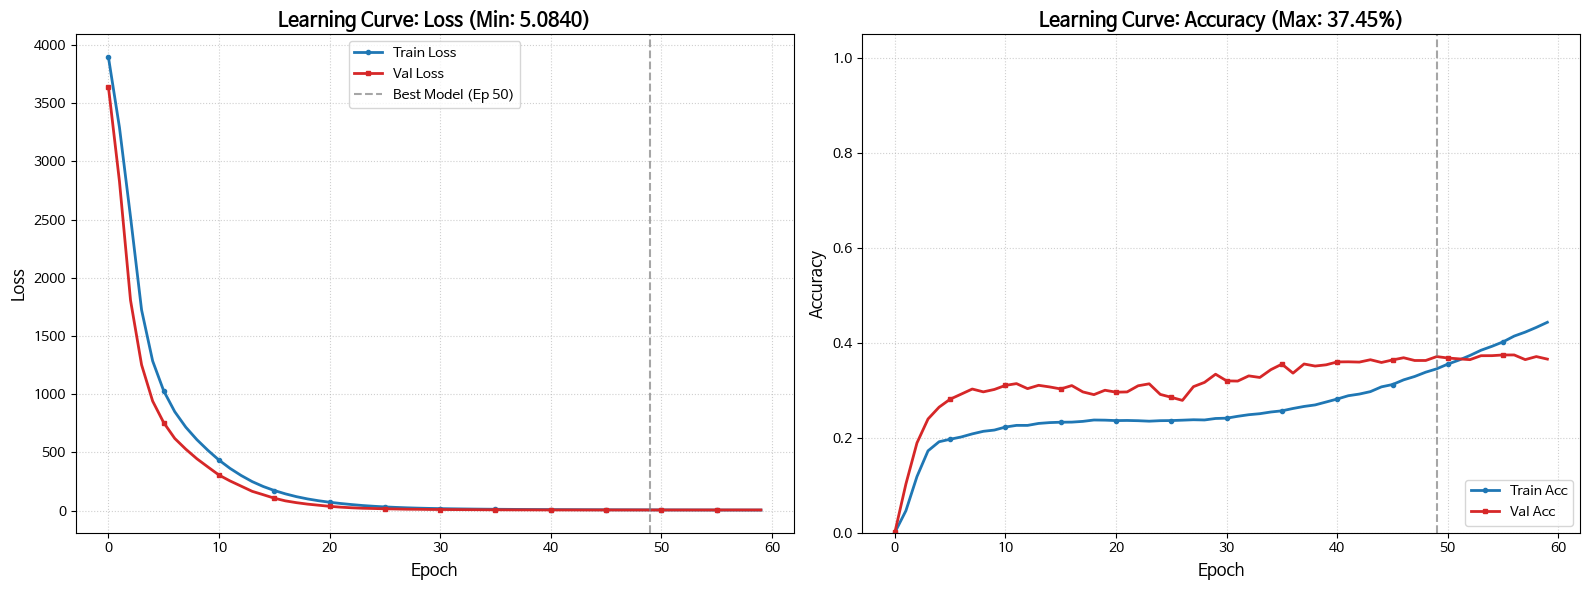

최적의 성능을 보인 에폭: 50
'wirobot_learning_result.png' 파일로 저장이 완료되었습니다.


In [56]:
# 학습 곡선 시각화

# 1. 스타일 및 폰트 설정
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. 최적의 에폭 찾기 (Val Loss가 가장 낮은 지점)
best_ep = val_losses.index(min(val_losses))

# --- [첫 번째 그래프] Loss Curve ---
axes[0].plot(train_losses, label='Train Loss', color='#1f77b4', lw=2, marker='o', ms=3, markevery=5)
axes[0].plot(val_losses,   label='Val Loss',   color='#d62728', lw=2, marker='s', ms=3, markevery=5)
# 최적 에폭에 수직선 표시
axes[0].axvline(x=best_ep, color='gray', ls='--', alpha=0.7, 
                label=f'Best Model (Ep {best_ep+1})')

axes[0].set_title(f'Learning Curve: Loss (Min: {min(val_losses):.4f})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].grid(True, ls=':', alpha=0.6)

# --- [두 번째 그래프] Accuracy Curve ---
axes[1].plot(train_accs, label='Train Acc', color='#1f77b4', lw=2, marker='o', ms=3, markevery=5)
axes[1].plot(val_accs,   label='Val Acc',   color='#d62728', lw=2, marker='s', ms=3, markevery=5)
axes[1].axvline(x=best_ep, color='gray', ls='--', alpha=0.7)

# 정확도 그래프는 0~100% 사이를 명확히 보여주는 것이 좋음
axes[1].set_ylim(0, 1.05) 
axes[1].set_title(f'Learning Curve: Accuracy (Max: {max(val_accs):.2%})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, ls=':', alpha=0.6)

# 3. 레이아웃 정리 및 저장
plt.tight_layout()
plt.savefig('wirobot_learning_result.png', dpi=150)
plt.show()

print(f"최적의 성능을 보인 에폭: {best_ep + 1}")
print(f"'wirobot_learning_result.png' 파일로 저장이 완료되었습니다.")

- Train/Val Loss가 모두 초반 20 에폭(Epoch) 이내에 급감하며 수렴하는 듯 보이나, Accuracy 그래프를 보면 50 에폭 이후 Train Acc는 꾸준히 상승하는 반면 Val Acc는 `37.45%`에서 정체되는 과적합 징후를 보였다.

- 최저 Loss가 `5.0840`까지 떨어졌음에도 불구하고 정확도가 `37.45%`에 머문다는 것은, 모델이 손실 함수를 줄이기 위해 문장의 실제 의미보다는 빈번하게 등장하는 특정 토큰(어미 등)의 확률을 높이는 데만 집중했을 가능성을 시사한다.

In [57]:
# 최고 성능 모델 확인
checkpoint = torch.load('best_wirobot_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

print(f"최고 성능 모델 로드! Epoch: {checkpoint['epoch']+1}")
print(f"Val Loss: {checkpoint['val_loss']:.4f} | Val Acc: {checkpoint['val_acc']:.2%}")

print("\n" + "="*25 + " 최종 위로봇 답변 " + "="*25)

model.eval()
with torch.no_grad():
    for i, q in enumerate(test_questions, 1):
        # 1. 모델로부터 답변 생성
        raw_ans = predict_answer(model, q, word_index, index_word, mecab, device,
                                 max_len=MAX_SEQ_LEN, temperature=inference_temp)
        
        # 2. 띄어쓰기 및 가독성 수정
        # 형태소 사이의 공백을 제거하고, Mecab의 공백 기호( )를 실제 공백으로 복구
        clean_ans = raw_ans.replace(' ', '').replace(' ', ' ').strip()
        
        # 3. 결과 출력
        print(f"{i}. Q: {q}")
        print(f"   A: {clean_ans}\n")

print("="*66)

최고 성능 모델 로드! Epoch: 50
Val Loss: 5.0840 | Val Acc: 37.11%

========================= 최종 위로봇 답변 =========================
1. Q: 지루하다, 놀러가고 싶어.
   A: 같이놀러가있어요.

2. Q: 오늘 일찍 일어났더니 피곤하다.
   A: 오늘은안괜찮아질거예요.

3. Q: 간만에 여자친구랑 데이트 하기로 했어.
   A: 제가필요해요.

4. Q: 집에 있는다는 소리야.
   A: 야경인가봐요.



## 7. 성능 평가

### 7-1. BLEU Score 기반

In [52]:
def calculate_bleu(reference, candidate, weights=(0.25, 0.25, 0.25, 0.25)):
    """BLEU Score 계산"""
    return sentence_bleu(
        [reference], candidate,
        weights=weights,
        smoothing_function=SmoothingFunction().method1
    )

def calculate_bleu_for_chatbot(model, src_list, tgt_list,
                                word_index, index_word, mecab, device,
                                max_len=MAX_SEQ_LEN, temperature=0.3,
                                sample_size=200):
    """
    검증 데이터 sample_size개를 샘플링하여 평균 BLEU 계산.
    tgt_list: 정수 인코딩된 dec_train 행 (토큰 ID 리스트)
    """
    idx_to_word = index_word
    indices     = random.sample(range(len(src_list)), min(sample_size, len(src_list)))
    scores      = []

    for idx in tqdm(indices, desc='BLEU 평가'):
        # 소스: 원본 que_corpus 문자열 복원
        q_tokens = [idx_to_word.get(i, '') for i in src_list[idx] if i != 0]
        q_str    = ' '.join(q_tokens)

        # 레퍼런스: 정수 ID → 토큰 (PAD, <start>, <end> 제외)
        ref = [idx_to_word.get(i, '') for i in tgt_list[idx]
               if i not in (0, START_IDX, END_IDX)]

        ans = predict_answer(model, q_str, word_index, index_word, mecab, device,
                             max_len=max_len, temperature=temperature)
        hyp = list(ans)   # 형태소 단위이므로 문자 단위 BLEU

        if not hyp:
            continue
        scores.append(calculate_bleu(ref, hyp))

    avg = sum(scores) / len(scores) if scores else 0.0
    return avg, scores

In [53]:
print("BLEU Score 평가 중... (검증 데이터 100개 샘플)")

# 검증 데이터의 원본 인덱스
val_enc_list = enc_train[split_idx:].tolist()
val_dec_list = dec_train[split_idx:].tolist()

avg_bleu, bleu_scores = calculate_bleu_for_chatbot(
    model, val_enc_list, val_dec_list,
    word_index, index_word, mecab, device,
    max_len=MAX_SEQ_LEN, temperature=inference_temp, sample_size=100
)

print(f"\n평균 BLEU Score: {avg_bleu:.4f}")
print(f"최고 BLEU Score: {max(bleu_scores):.4f}")
print(f"최저 BLEU Score: {min(bleu_scores):.4f}")

BLEU Score 평가 중... (검증 데이터 100개 샘플)


BLEU 평가:   0%|          | 0/100 [00:00<?, ?it/s]


평균 BLEU Score: 0.0115
최고 BLEU Score: 0.0377
최저 BLEU Score: 0.0000


In [54]:
# 개별 예시 BLEU 확인 (검증 첫 5개)
idx_to_word = index_word
print("\n===== 개별 BLEU 예시 (검증 데이터 첫 5개, 온도 = 0.3) =====")
for i in range(min(5, len(val_enc_list))):
    q_tokens = [idx_to_word.get(j, '') for j in val_enc_list[i] if j != 0]
    q_str    = ' '.join(q_tokens)
    ref      = [idx_to_word.get(j, '') for j in val_dec_list[i]
                if j not in (0, START_IDX, END_IDX)]
    ans      = predict_answer(model, q_str, word_index, index_word, mecab, device,
                              max_len=MAX_SEQ_LEN, temperature=inference_temp)
    score    = calculate_bleu(ref, list(ans))
    print(f"Q    : {q_str}")
    print(f"정답 : {''.join(ref)}")
    print(f"예측 : {ans}")
    print(f"BLEU : {score:.4f}\n")


===== 개별 BLEU 예시 (검증 데이터 첫 5개) =====
Q    : 오늘 연락 왔 네 정말 이젠 안녕
정답 : 정말안녕.
예측 : 안녕 .
BLEU : 0.0803

Q    : 오늘 <unk> 왔 어
정답 : 기다리던연락이었길바랍니다.
예측 : 오늘 은 길 바랍니다 .
BLEU : 0.0185

Q    : 내일 유난히 우리 가 더 힘든 이유
정답 : 기억될어느날이었나봅니다.
예측 : 오늘 은 찾아오 네요 .
BLEU : 0.0155

Q    : 오늘 이 별하 러 이 !
정답 : 맘고생많았어요.
예측 : 오늘 은 시간 이 올 거 예요 .
BLEU : 0.0108

Q    : 오늘 사랑 했 습니다
정답 : 믿기지않겠네요.
예측 : 오늘 도 힘들 었 나 봐요 .
BLEU : 0.0123



In [68]:
# 개별 예시 BLEU 확인 (검증 첫 5개)
predict_temp = 0.8
print("\n===== 개별 BLEU 예시 (검증 데이터 첫 5개, 온도 = 0.8) =====")
for i in range(min(5, len(val_enc_list))):
    q_tokens = [idx_to_word.get(j, '') for j in val_enc_list[i] if j != 0]
    q_str    = ' '.join(q_tokens)
    ref      = [idx_to_word.get(j, '') for j in val_dec_list[i]
                if j not in (0, START_IDX, END_IDX)]
    ans      = predict_answer(model, q_str, word_index, index_word, mecab, device,
                              max_len=MAX_SEQ_LEN, temperature=predict_temp)
    score    = calculate_bleu(ref, list(ans))
    print(f"Q    : {q_str}")
    print(f"정답 : {''.join(ref)}")
    print(f"예측 : {ans}")
    print(f"BLEU : {score:.4f}\n")


===== 개별 BLEU 예시 (검증 데이터 첫 5개, 온도 = 0.8) =====
Q    : 오늘 연락 왔 네 정말 이젠 안녕
정답 : 정말안녕.
예측 : 안녕 .
BLEU : 0.0803

Q    : 오늘 <unk> 왔 어
정답 : 기다리던연락이었길바랍니다.
예측 : 오늘 었 나요 .
BLEU : 0.0285

Q    : 내일 유난히 우리 가 더 힘든 이유
정답 : 기억될어느날이었나봅니다.
예측 : 오늘 가 왔 지만 않 아푸 나 봐요 .
BLEU : 0.0109

Q    : 오늘 이 별하 러 이 !
정답 : 맘고생많았어요.
예측 : 오늘 자던 피시방 화 올 거 예요 .
BLEU : 0.0096

Q    : 오늘 사랑 했 습니다
정답 : 믿기지않겠네요.
예측 : 오늘 대외 뇌세포 했 지 않 길 바랍니다 .
BLEU : 0.0104



전반적으로 BLEU 점수가 10%도 채 넘지 않는 예측 케이스가 많다. 혹시 공백과 토큰화 복원이 잘안되어 그런 건가 싶어 이 문제를 해결해 아래에서 다시 BLEU 점수를 계산한다.

### 7-2. 개선된 BLEU Score 기반

In [67]:
# 개별 BLEU 계산 함수 (형태소 기반)
def calculate_token_bleu(ref_str, pred_str, mecab):
    # 정답과 예측의 모든 공백을 제거한 뒤 다시 형태소 분석 -> 보다 공정한 비교
    ref_tokens = mecab.morphs(ref_str.replace(" ", ""))
    pred_tokens = mecab.morphs(pred_str.replace(" ", ""))
    
    smoothie = SmoothingFunction().method1
    return sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoothie)

In [69]:
predict_temp = 0.8
print(f"\n===== 개별 BLEU 예시 (검증 데이터 첫 5개, 온도 = {predict_temp}) =====")
print("-" * 80)

for i in range(min(5, len(val_enc_list))):
    # 질문 인덱스를 토큰으로 변환 (불필요한 PAD 등 제거)
    q_tokens = [idx_to_word.get(j, '') for j in val_enc_list[i] if j not in (0,)]
    q_str_raw = ' '.join(q_tokens)
    
    # [추가] 조각난 질문을 보기 좋게 합침 (decode_mecab_input 적용)
    q_clean = q_str_raw.replace(" ", "").replace("<unk>", "[모르는단어]")
    
    # 정답(Ref) 구성
    ref_tokens_list = [idx_to_word.get(j, '') for j in val_dec_list[i] 
                       if j not in (0, START_IDX, END_IDX)]
    ref_str_joined = "".join(ref_tokens_list)
    
    # 모델 예측
    ans_raw = predict_answer(model, q_str_raw, word_index, index_word, mecab, device, 
                             max_len=MAX_SEQ_LEN, temperature=predict_temp)
    
    # [추가] 예측 답변도 깔끔하게 합침
    ans_clean = ans_raw.replace(" ", "")
    
    # [수정] 형태소 기반 BLEU 계산
    score = calculate_token_bleu(ref_str_joined, ans_raw, mecab)
    
    print(f"Q (원본느낌) : {q_clean}")
    print(f"정답(Ref)   : {ref_str_joined}")
    print(f"예측(Pred)  : {ans_clean}")
    print(f"BLEU Score  : {score:.4f}")
    print("-" * 80)


===== 개별 BLEU 예시 (검증 데이터 첫 5개, 온도 = 0.8) =====
--------------------------------------------------------------------------------
Q (원본느낌) : 오늘연락왔네정말이젠안녕
정답(Ref)   : 정말안녕.
예측(Pred)  : 안녕도안녕.
BLEU Score  : 0.1699
--------------------------------------------------------------------------------
Q (원본느낌) : 오늘[모르는단어]왔어
정답(Ref)   : 기다리던연락이었길바랍니다.
예측(Pred)  : 오늘이길바랍니다.
BLEU Score  : 0.1568
--------------------------------------------------------------------------------
Q (원본느낌) : 내일유난히우리가더힘든이유
정답(Ref)   : 기억될어느날이었나봅니다.
예측(Pred)  : 오늘은부모님은그런사람으로돌아갈거예요.
BLEU Score  : 0.0170
--------------------------------------------------------------------------------
Q (원본느낌) : 오늘이별하러이!
정답(Ref)   : 맘고생많았어요.
예측(Pred)  : 싱숭생숭했나봐요.
BLEU Score  : 0.0537
--------------------------------------------------------------------------------
Q (원본느낌) : 오늘사랑했습니다
정답(Ref)   : 믿기지않겠네요.
예측(Pred)  : 오늘이길바랍니다.
BLEU Score  : 0.0440
--------------------------------------------------------------------------------


약간의 점수 상승이 보이지만 이번에 채택된 문장이 쉬워서 우연히 BLEU 점수가 향상되었을 가능성이 있다. 이번에는 개별 문장 말고 전체 검증 데이터를 기반으로 코사인 유사도 계산을 통해 정답과 예측 간의 모양 차이가 아닌 의미적 차이를 비교한다.

### 7-3. 코사인 유사도 기반

In [73]:
def get_total_semantic_similarity(model, val_enc_list, val_dec_list, idx_to_word, word_index, mecab, device):
    model.eval()
    total_sim = 0
    count = 0
    
    print(f"{'정답(Reference)':<20} | {'예측(Prediction)':<20} | {'Similarity'}")
    print("-" * 70)
    
    with torch.no_grad():
        for i in range(len(val_enc_list)): # 전체 평균 산출을 위한 loop
            # 1. 질문 및 정답 추출
            q_tokens = [idx_to_word.get(j, '') for j in val_enc_list[i] if j != 0]
            q_str = ' '.join(q_tokens)
            
            ref_tokens = [idx_to_word.get(j, '') for j in val_dec_list[i] if j not in (0, START_IDX, END_IDX)]
            ref_str = "".join(ref_tokens)
            
            # 2. 모델 예측 답변 생성
            pred_str = predict_answer(model, q_str, word_index, index_word, mecab, device, 
                                      max_len=MAX_SEQ_LEN, temperature=1.0)
            pred_clean = pred_str.replace(" ", "")
            
            # 3. 임베딩 벡터 추출 함수 (Mean Pooling)
            def get_vec(text):
                '''문장을 벡터로 전환'''
                tks = mecab.morphs(text.replace(" ", ""))
                ids = [word_index.get(t, word_index.get('<unk>', 0)) for t in tks]
                if not ids: return torch.zeros(1, d_model).to(device)
                emb = model.enc_emb(torch.tensor([ids]).to(device)) # 임베딩 추출 -> 각 단어가 256 차원의 벡터가 됨
                return emb.mean(dim=1) # 문장에 포함된 여러 단어 벡터들의 평균 -> 문장 전체의 의미를 담은 하나의 대표 벡터

            vec_ref = get_vec(ref_str)
            vec_pred = get_vec(pred_clean)
            
            # 4. 코사인 유사도 계산
            # 두 벡터(정답 벡터 vs 예측 벡터)가 공간상에서 얼마나 같은 방향을 가리키고 있는지 계산
            sim = F.cosine_similarity(vec_ref, vec_pred).item()
            total_sim += sim
            count += 1
            
            # 상위 10개만 예시 출력
            if i < 10:
                print(f"{ref_str[:18]:<20} | {pred_clean[:18]:<20} | {sim:.4f}")
                
    avg_sim = total_sim / count
    return avg_sim

In [81]:
avg_similarity = get_total_semantic_similarity(model, val_enc_list, val_dec_list, idx_to_word, word_index, mecab, device)
print(f"\n 전체 검증 데이터 평균 유사도: {avg_similarity:.4f}")

정답(Reference)        | 예측(Prediction)       | Similarity
----------------------------------------------------------------------
정말안녕.                | 안녕.                  | 0.7060
기다리던연락이었길바랍니다.       | 오늘죽음적아니면샜네요.         | 0.2647
기억될어느날이었나봅니다.        | 오늘택배모아야이길바랍니다.       | 0.0819
맘고생많았어요.             | 오늘뗄길바랍니다.            | 0.1243
믿기지않겠네요.             | 찔러보길바랍니다.            | 0.2861
지켜만보는편이나을거예요.        | 처리한행동마셔요.            | 0.3128
언젠간닥쳐올순간일거예요.        | 미련을누군가찌푸려지않겠어요.      | 0.1861
진심이전해지길바랍니다.         | 오늘건데짧은힘들발목부산라네네요.    | 0.2211
오늘도스스로이겨냈어요.         | 오늘생긴다고의단점그리워세요.      | 0.4673
잘지냈답니다.              | 오늘광합성추천정규직거예요.       | 0.0956

 전체 검증 데이터 평균 유사도: 0.3867


유사도 `0.3`이란 수치가 나타내는 바는 모델이 문맥을 잡지 못하고 단어들을 무작위로 조합하다가 가끔 운 좋게 비슷한 단어를 맞히는 상태라는 것이다. 위에 생성된 답변들을 보건대 데이터 내에 노이즈로 작용한 단어가 많았던 것으로 보인다.  

아래 셀에서 위에 등장한 노이즈 단어가 포함된 행이 (질문 - 답변 쌍) 얼마나 많은지 알아본다.

In [83]:
# '정규직', '광합성', '택배' 등의 단어가 포함된 원본 데이터를 찾습니다.
target_words = ['정규직', '광합성', '택배', '부산', '죽음', '빵빵', '바랍니다']
noise_check = df[df['Q'].str.contains('|'.join(target_words)) | 
                       df['A'].str.contains('|'.join(target_words))]

print(f" 의심되는 노이즈 데이터 개수: {len(noise_check)}")
if not noise_check.empty:
    display(noise_check.head(10)) # 데이터프레임 형태로 깔끔하게 확인
else:
    print(" 데이터셋에는 해당 단어가 없습니다. 모델의 '환각(Hallucination)'일 가능성이 큽니다!")

 의심되는 노이즈 데이터 개수: 123


,Q,A,label
810,내 인생은 가시밭길 같아,꽃길만 걷길 바랍니다.,0
877,내가 희생양이 됐어,일방적 희생양이 되지 않길 바랍니다.,0
1091,늘 빡빡하게 살기 힘드네,여유가 생기길 바랍니다.,0
1257,도서관 가서 공부해야지,열심히 공부하길 바랍니다.,0
1258,도서관 가야지,열심히 공부하길 바랍니다.,0
1297,돈 빌려줬는데 연락 두절,차용증 썼길 바랍니다.,0
1298,돈 빌려줬는데 잠수탔어,차용증 썼길 바랍니다.,0
1402,또 개강이라니,즐거운 시작 되길 바랍니다.,0
1403,또 개강이야,즐거운 시작 되길 바랍니다.,0
1557,맛집 다녀왔어,맛있게 드시고 오셨길 바랍니다.,0


**'정규직', '광합성', '택배' 등 이별/슬픔이나 연애/사랑 클래스와 크게 상관없는 단어가 123건 발견되었다.**  

전체 단어 수 중 노이즈라 할 만한 단어에는 어떤 것들이 있는지, 또 이들이 차지하는 비율이 얼마가 더 필요한지 알아볼 필요가 있겠으나, 당장은 **모델이 이들 단어를 잘못된 맥락에서 학습하여 엉뚱한 답변을 생성하는 원인**이 된 것은 확실하다고 할 수 있다.

### 7-4. 사용자 대화 기반

In [84]:
def chat_with_wirobot(model, word_index, index_word, mecab, device, temp=0.7):
    """답변 속도 측정이 포함된 위로봇 대화 인터페이스"""
    model.eval()
    print(" 위로봇과 대화를 시작합니다! (종료: '종료' 또는 'exit')")
    print("-" * 50)
    
    while True:
        user_input = input("질문을 입력하세요: ")
        
        if user_input.lower() in ['종료', 'exit', 'quit']:
            display(Markdown(f"**👩🏻 나:** {user_input}"))
            display(Markdown(f"**🤗 위로봇:** 다음에 또 만나요!"))
            break
            
        if not user_input.strip():
            continue
            
        # 1. 사용자 입력 출력
        display(Markdown(f"**👩🏻 나:** {user_input}"))
        
        # 2. 답변 생성 시간 측정 시작
        start_time = time.time()
        
        # 3. 모델 답변 생성
        ans = predict_answer(model, user_input, word_index, index_word, mecab, device, 
                             max_len=MAX_SEQ_LEN, temperature=temp)
        
        # 4. 측정 종료 및 계산
        end_time = time.time()
        inference_time = end_time - start_time
        
        # 5. 모델 답변 및 소요 시간 출력
        display(Markdown(f"**🤗 위로봇:** {ans}"))
        print(f" 소요 시간: {inference_time:.3f}초")
        display(Markdown("---"))

In [88]:
# 채팅 루프 실행
chat_with_wirobot(model, word_index, index_word, mecab, device, temp=0.6)

 위로봇과 대화를 시작합니다! (종료: '종료' 또는 'exit')
--------------------------------------------------


질문을 입력하세요:  안녕!


**👩🏻 나:** 안녕!

**🤗 위로봇:** 안녕 .

 소요 시간: 0.020초


...

 소요 시간: 0.018초


---

질문을 입력하세요:  종료


**👩🏻 나:** 종료

**🤗 위로봇:** 다음에 또 만나요!

In [89]:
# 답변 제출
chat_with_wirobot(model, word_index, index_word, mecab, device, temp=1.0) # 온도를 높여 다시 테스트

 위로봇과 대화를 시작합니다! (종료: '종료' 또는 'exit')
--------------------------------------------------


질문을 입력하세요:  안녕!


**👩🏻 나:** 안녕!

**🤗 위로봇:** 안녕 .

 소요 시간: 0.016초


...

 소요 시간: 0.047초


---

질문을 입력하세요:  종료


**👩🏻 나:** 종료

**🤗 위로봇:** 다음에 또 만나요!

- 챗봇이 방금 자기가 한 말도 기억하지 못하고 사용자의 감정 변화에 대응하기보다 매 순간 가장 확률 높은 단어만 거의 무작위로 조합해 출력하고 있다.

- "하세요", "있어요", "바랍니다" 같은 어미가 단조롭게 반복되는 건 데이터셋에 자주 등장한 종결어미 쪽으로 모델이 편향되었기 때문이다. 온도 매개변수 `temp`를 `0.6`에서 `1.0`으로 높여 답변에 창의성을 주입하려는 시도도 소용이 없을 정도였다.

- 챗봇의 답변 속도 자체는 준수하다. 일반적인 고성능 챗봇과 비교했을 때 답변 소요 시간이 많이 짧은 수준인데, 이는 오히려 위로봇의 추론이 너무 단순함을 드러낸다. **답변 시간을 다소 희생하더라도 사람이 이해가능한 형태의 말을 하는 챗봇을 만들 필요가 있다.** 

- 또 성능이 이렇다 보니 사용자가 오해할 만한 답변을 하거나 (전 에 신고 해요 등) 사용자의 질문에서 위험 신호를 잡아 (소리지른다니, 누가? 너 이상해 등) 대응하는 능력 또한 없다.

## 회고

과제 수행 단계 기준 회고를 작성했다.

- **EDA:**

   데이터셋의 통계적 분포는 확인했으나 내용 측면에서는 파악을 잘 하지 못해 학습에 방해가 되는 많은 양의 노이즈를 걸러내지 못했다. 데이터셋을 살피며 지나친 노이즈가 섞인 행을 아예 제거하는 방향도 추가했어야 한다는 생각이 든다.

- **데이터 증강:**

  Lexical substitution 증강과 무작위 삭제와 교체로 데이터를 3배 늘렸음에도 모델이 학습하기 좋은 다양성을 증가시키기에는 부족했던 것 같다. 제한이 없다면 생성 모델을 통한 문장 생성이나 타 메신저 대화 데이터를 합쳤어도 될 것 같다는 생각이 들었다.

- **모델 훈련 전후:**

  아마 실제 서비스를 개발하는 중이었다면 학습 로그를 보고 바로 방향을 수정했을 것이다. 특히 현재 사용 중인 모델을 고도화하는 데 드는 비용를 감당하기 보다는 언어적 상식이 이미 학습된 사전 학습 모델(KoGPT2 등)을 도입해 기본 품질을 확보한 뒤 특정 도메인(위로)에 특화된 fine-tuning을 진행하는 편이 타당하다.

- 참고 문헌:

  * [코더의 이전 트랜스포머 챗봇 과제 (Ex09)](https://github.com/laladna/AIFFEL_quest_rs/blob/master/Exploration/Ex09/Ex09.ipynb)